In [1]:
import pandas as pd
from time import perf_counter

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

In [3]:
from models import DecisionTreeClassifier, NaiveBayesClassifier
from preprocessing import train_test_split, LabelEncoder, OrdinalEncoder
import visuals as vis

In [4]:
df = pd.read_csv("../data/raw/mushroom_csv.csv")
df.head()

,cap-shape,cap-surface,cap-color,bruises%3F,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


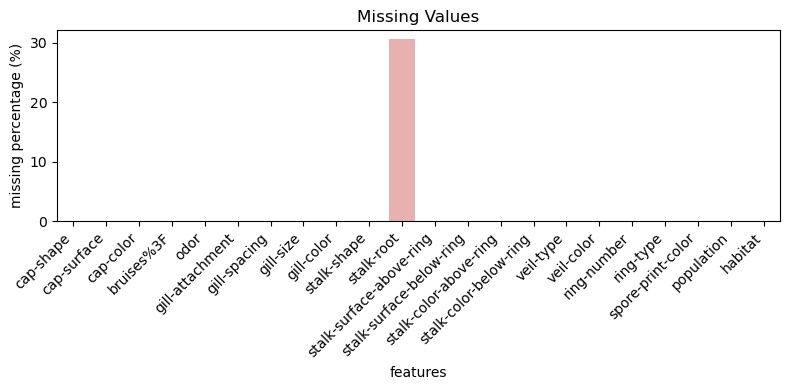

In [5]:
vis.plot_missing_values(df.drop(['class'], axis=1))
df = df.fillna('None')

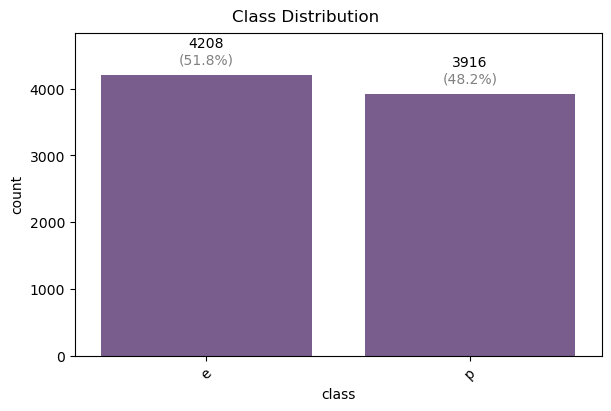

In [6]:
Y = df['class'].values
X = df.drop(['class'], axis=1).values


vis.plot_class_distribution(Y)

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y)

In [8]:
le = LabelEncoder()
oe = OrdinalEncoder()

Y_train = le.fit_transform(Y_train)
Y_test  = le.transform(Y_test)

X_train = oe.fit_transform(X_train, Y_train)
X_test  = oe.transform(X_test)

In [9]:
m1 = DecisionTreeClassifier(max_depth=2, min_gain=0.3)
m2 = DecisionTreeClassifier(max_depth=3, min_gain=0.05)
m3 = DecisionTreeClassifier(max_depth=6, min_gain=0.001)
m4 = NaiveBayesClassifier()

models = [m1, m2, m3, m4]
fit_times = []

for m in models:
    start = perf_counter()
    m.fit(X_train, Y_train)
    end = perf_counter()

    fit_times.append(end - start)


In [10]:
for i, m in enumerate(models):
    score = m.score(X_test, Y_test)
    print(f"model {i+1}: {round(score.get('accuracy'), 4)}, fitting time: {round(fit_times[i], 4)}")

model 1: 0.9824, fitting time: 0.0662
model 2: 0.9967, fitting time: 0.1083
model 3: 1.0, fitting time: 0.1128
model 4: 0.9471, fitting time: 0.0099


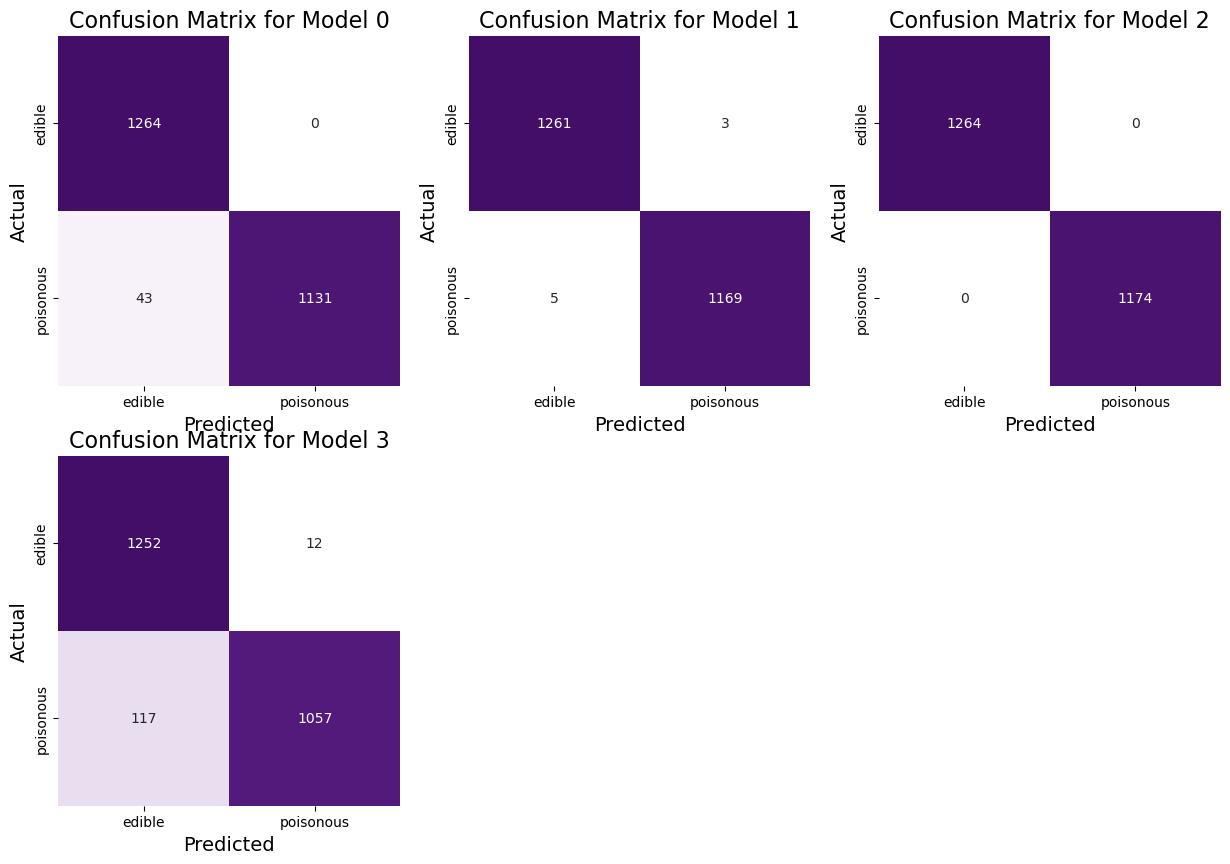

In [11]:
conf_mats = [m.score(X_test, Y_test, scores=["confusion_matrix"], onlyvalues=True)[0] for m in models]

vis.plot_confusion_matrices(
    conf_mats,
    ["edible", "poisonous"],
    titling=lambda i: f"Confusion Matrix for Model {i}"
)